# Study the use of BERT for Topic Modeling with BBC data
Based on "BERTopic: Neural topic modeling with a class-based TF-IDF procedure"
Reference: https://arxiv.org/pdf/2203.05794  

This notebook will do the following:
1. Train the BerTopic implemented in bertopic python library following on similar or same data as mentioned in section 5.1 of the paper. This notebook is for BBC:

    - b) BBC (static)

Sample processed cleaned data fromat for static files:

| Document         | Clean Text     | # word count |
|--------------|-----------|------------|
| broadband ahead join internet .... | broadband ahead join internet ...  |71      |

The notebook has following steps. The data preprocesing was done in preprocessing.ipynb and that code is separate. Here the preprocessed clean data is fed.
 - 1. Train function is using BERTopic fit_trannfrom() funtion
 - 2. Then do quantitative analysis as mentioned in section 5.3. usinf gensim python package CoherenceModel.
 - 3.Then do qualitative analysis as mentioned in section 5.3. by listing top words for any one of the topic say topic 0
 - 4. Do Visualization of topics using visulize_{functions} in BERTopic model.
 - 5. Save Model: topic_model.save("<DomainName>_bertopic_model")
 - 6. Model Inference on unseen data Here we create some unseen daat manually and see the inference. topic_model.transform(unseen_docs) will do the inference .

### Releavance Score also called importance or weigh.
BERTopic, these numbers come from a class-based TF-IDF variant called c-TF-IDF. It reflects:
How representative or important the word is for that specific topic, compared to all other topics.
Higher numbers = more defining for the topic.

## 1. Setup and Dependencies

### Optional: Mount Google Drive
Uncomment and run if you want to access files from your Google Drive

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


##Install dependencies


In [1]:
# Install dependencies
# !pip uninstall bertopic[all] umap-learn hdbscan sentence-transformers gensim pandas numpy -y
# Install dependencies
!pip install --upgrade pip
!pip install --upgrade numpy pandas bertopic[all] umap-learn hdbscan sentence-transformers gensim

  Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)


In [2]:
processed_data_path = "/content/drive/MyDrive/DLFA_IIsc_AIML/capstone_project/data_processed/" #set data path here
model_path="/content/drive/MyDrive/DLFA_IIsc_AIML/capstone_project/model/"
#data_path = "/content/drive/MyDrive/DLFA_IIsc_AIML/capstone_project/data/"

# Import libraries

In [3]:
import pandas as pd
import numpy as np
from IPython.display import display
import plotly.express as px

from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

## 2. Fit BERTopic (Training for a domain or dataset)

In [4]:
#load data BBC
import pandas as pd
bbc_file = processed_data_path + "bbc_news_mindLab_corpus.csv"
df = pd.read_csv(bbc_file)  # adjust the path
docs = df['clean_text'].dropna().tolist()  # adjust column name as needed

In [5]:
# Print first 5 cleaned documents
for i, doc in enumerate(docs[:5]):
    print(f"Document {i+1}:\n{doc}\n{'-'*40}")


Document 1:
broadband ahead join internet fast accord official figure number business connect jump report broadband connection end compare nation rank world telecom body election campaign ensure affordable high speed net access american accord report broadband increasingly popular research shopping download music watch video total number business broadband rise end compare hook broadband subscriber line technology ordinary phone line support high datum speed cable lead account line broadband phone line connection accord figure
----------------------------------------
Document 2:
plan share sale owner technology dominate index plan sell share public list market operate accord document file stock market plan raise sale observer step close public icon technology boom recently pour cold water suggestion company sell share private technically public stock start trade list equity trade money sale investor buy share private filing document share technology firm company high growth potential s

In [ ]:
# df_results = pd.DataFrame(results)
# print(df_results.pivot(index='n_topics', columns='model', values='TC'))

# Visualize reduced embedding abd predicted clusters

##Interactive Plots of reeduced Embeddings

In [6]:
def plot_reduced_embeddings():
  # 1. Prepare DataFrame
  df_plot = pd.DataFrame(reduced_embeddings[:, :2], columns=["x", "y"])  # 2D only
  df_plot["cluster"] = predicted_clusters
  df_plot["text"] = docs  # You can also use titles if available

  # 2. Plotly scatter plot with hover text
  fig = px.scatter(
  df_plot, x="x", y="y",
  color="cluster",
  hover_data={"text": True, "cluster": True, "x": False, "y": False},
  title="UMAP + HDBSCAN Clusters (Hover to See Document Text)",
  color_continuous_scale="Viridis" if df_plot["cluster"].nunique() > 10 else None
  )

  fig.update_traces(marker=dict(size=6, opacity=0.7), selector=dict(mode='markers'))
  fig.update_layout(legend_title="Cluster ID")
  fig.show()

In [2]:
# # Ensure predicted_clusters is a numpy array
# predicted_clusters = np.array(predicted_clusters)

# # Convert to a DataFrame for easy plotting
# import pandas as pd
# df_plot = pd.DataFrame(reduced_embeddings, columns=["x", "y","z"])
# df_plot["cluster"] = predicted_clusters

# # Plot
# plt.figure(figsize=(10, 7))
# palette = sns.color_palette("hsv", len(np.unique(predicted_clusters)))
# sns.scatterplot(data=df_plot, x="x", y="y", hue="cluster", palette=palette, s=60, legend="full")
# plt.title("UMAP Projection with HDBSCAN Clusters")
# plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

In [7]:
def save_model(model_name):
  bbc_model_file = model_path + "bbc_news_model_" + model_name
  topic_model.save(bbc_model_file)

## 3. Quantitative Validation

Topic Coherence measures how semantically related the top words in each topic are. A higher score means:

Top words in a topic frequently appear together in the original documents.

The topic is more interpretable to humans.

In [8]:
def compute_TC():
  # Get topics as word lists
  topics = topic_model.get_topics()
  topic_words = [[word for word, _ in topics[topic]] for topic in topics]

  # Prepare texts for coherence model (same ones used for BERTopic)
  texts = [doc.split() for doc in docs]  # assumes simple tokenization

  dictionary = Dictionary(texts)
  coherence_model = CoherenceModel(
      topics=topic_words,
      texts=texts,
      dictionary=dictionary,
      coherence='c_v'
  )
  coherence_score = coherence_model.get_coherence()
  print(f"Coherence Score: {coherence_score:.4f}")
  return coherence_score

### Topic Diversity

In [9]:
def  compute_TD():
  # Step 1: Load SBERT or any word embedding model to get word vectors
  s_model = SentenceTransformer('all-MiniLM-L6-v2')  # A lightweight SBERT model

  # Step 2: Extract the top words for each topic
  topic_words = {topic_id: [word for word, _ in topic_model.get_topic(topic_id)[:5]] for topic_id in topic_model.get_topic_info().Topic if topic_id != -1}

  # Step 3: Get embeddings for all top words in each topic
  topic_embeddings = {}
  for topic_id, words in topic_words.items():
      topic_embeddings[topic_id] = s_model.encode(words)

  # Step 4: Compute pairwise cosine similarity between topics
  similarity_matrix = np.zeros((len(topic_embeddings), len(topic_embeddings)))
  topic_ids = list(topic_embeddings.keys())

  for i, topic_id_1 in enumerate(topic_ids):
      for j, topic_id_2 in enumerate(topic_ids):
          if i != j:
              similarity_matrix[i, j] = cosine_similarity([topic_embeddings[topic_id_1].mean(axis=0)], [topic_embeddings[topic_id_2].mean(axis=0)])[0, 0]

  # Step 5: Calculate diversity (1 - average similarity)
  average_similarity = similarity_matrix[np.triu_indices_from(similarity_matrix, 1)].mean()  # Only upper triangle (unique pairs)
  diversity = 1 - average_similarity
  print(f"Topic Diversity: {diversity:.4f}")
  return diversity

In [10]:
def display_topic_model():
  display(topic_model.visualize_topics())
  display(topic_model.visualize_barchart(top_n_topics=10))
  display(topic_model.visualize_hierarchy())

### Make a lookup where topic ID has a human readable Name
While BERTopic gives you numeric topic IDs (like 2, 5, 7), those numbers by themselves don't have meaning — they just group similar documents.

To make sense of these topics, you look at their top keywords, and based on that, you assign a human-readable name to each topic.

Python code that automatically generates a table of topic IDs, their top keywords, and a suggested name (based on top 3–5 keywords) from your trained BERTopic model.

In [11]:
def create_topic_labels():
  # Number of top words per topic to use for naming
  top_n_words = 5

  # Get all topic IDs (excluding outlier -1)
  topic_info = topic_model.get_topic_info()
  valid_topics = topic_info[topic_info.Topic != -1].Topic.tolist()

  # Build a table with topic ID, top words, and label
  topic_labels = []

  for topic_id in valid_topics:
      words = topic_model.get_topic(topic_id)
      top_words = [word for word, _ in words[:top_n_words]]
      label = ", ".join(top_words)
      topic_labels.append({
          "Topic ID": topic_id,
          "Topic Related To": f"{top_words[0].capitalize()}",
          "Top Words": label

      })

  return topic_labels

#Fit the model (you can also use precomputed embeddings)

In [16]:
embeddings = None
reduced_embeddings = None
predicted_clusters = None
topic_model = None
topic_range = [10, 20, 30, 40, 50]
SEED=40
results = []

In [14]:
embedding_models = {
    "MiniLM": SentenceTransformer("all-MiniLM-L6-v2"),
    "MPNET": SentenceTransformer("all-mpnet-base-v2"),
    "USE": SentenceTransformer("sentence-transformers/LaBSE"),
    # "Doc2Vec": "doc2vec"  # You need to load this separately
}


In [19]:
for model_name, embedding_model in embedding_models.items():
    for n_topics in topic_range:
        tc_scores = []
        td_scores = []
        for run in range(3):  # 3 seeds per config
            umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                              metric="cosine", random_state=SEED + run)
            hdbscan_model = HDBSCAN(min_cluster_size=15, metric="euclidean",
                                    cluster_selection_method="eom",
                                    prediction_data=True)

            topic_model = BERTopic(
                embedding_model=embedding_model,
                umap_model=umap_model,
                hdbscan_model=hdbscan_model,
                vectorizer_model=CountVectorizer(stop_words="english"),
                verbose=False,
                nr_topics=n_topics  # Forces number of topics
            )

            embeddings = embedding_model.encode(docs, show_progress_bar=True)

            # reduced_embeddings = umap_model.fit_transform(embeddings)
            # predicted_clusters = hdbscan_model.fit_predict(reduced_embeddings)


            topics, _ = topic_model.fit_transform(docs,embeddings)
            reduced_embeddings = topic_model.umap_model.transform(embeddings)
            predicted_clusters = topic_model.hdbscan_model.labels_


            tc = compute_TC()
            td = compute_TD()
            tc_scores.append(tc)
            td_scores.append(td)

        results.append({
            "model": model_name,
            "n_topics": n_topics,
            "TC": np.mean(tc_scores),
            "TD": np.mean(td_scores)
        })
        save_model(model_name)

        #Qualitative Validation
        print("-----------" + model_name + "--------------")
        topic_model.get_topic_info().head()
        topic_model.get_topic(0)  # Top words for topic 0

        #Representative Docs
        topic_model.get_representative_docs(0)[:3]  # Inspect 3 sample docs from topic 0

        #display topic model fitted
        # display_topic_model()
        display(topic_model.visualize_topics())
        display(topic_model.visualize_barchart(top_n_topics=10))
        display(topic_model.visualize_hierarchy())

        #create meaningfull topic lables instead of number 0,1,2,etc
        topic_labels = create_topic_labels()

        # Create and display a DataFrame
        df_labels = pd.DataFrame(topic_labels)
        print(df_labels.to_string(index=False))

        # Create a dictionary from the DataFrame to map topic id to s
        topic_name_map = dict(zip(df_labels["Topic ID"], df_labels["Topic Related To"]))

        # #Inference or model validation with unseen data
        new_topics, new_probs = topic_model.transform(["Fans around the world are downloading the new charity single released to support global disaster relief. Featuring international stars and backed by major record labels, the song has already topped charts in several countries. Music stores are reporting high demand, and digital platforms have seen a surge in streaming. Proceeds will go toward humanitarian aid, with organizers hopeful the track will raise millions. Industry experts compare the success to the original Band Aid release, which became a cultural milestone decades ago."])
        print(f"Assigned topic: {new_topics[0]}")
        #print relavance score:
        topic_words = topic_model.get_topic(new_topics[0])
        print(f"Top words for topic / Relavance Score {new_topics[0]}:  {topic_words}")


        unseen_docs = [
          "The government announced a new policy on education reform today.",
          "Manchester United won their match after a thrilling penalty shootout.",
          "Scientists discovered a new exoplanet that could support life.",
          "The singer released a new charity single to raise funds for disaster relief.",
          "A major tech company unveiled its latest AI-powered smartphone."
        ]

        topics, probs = topic_model.transform(unseen_docs)

        for i, doc in enumerate(unseen_docs):
            topic_id = topics[i]
            topic_name = topic_name_map.get(topic_id, "Unknown or Outlier Topic")

            print(f"\nDocument {i+1}: {doc}")
            print(f"Assigned topic: {topic_id}")
            print(f"Topic Related To: {topic_name}")
            print("Top words:", topic_model.get_topic(topics[i]))


Batches:   0%|          | 0/70 [00:00<?, ?it/s]

Coherence Score: 0.6463
Topic Diversity: 0.3959


Batches:   0%|          | 0/70 [00:00<?, ?it/s]

Coherence Score: 0.6931
Topic Diversity: 0.4213


Batches:   0%|          | 0/70 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/70 [00:00<?, ?it/s]

Coherence Score: 0.6767


2025-05-16 13:11:50,501 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Topic Diversity: 0.3549
-----------USE--------------


 Topic ID Topic Related To                                 Top Words
        0             Test               test, drug, iaaf, dope, ban
        1              Win            win, play, game, player, match
        2       Government government, election, party, plan, labour
        3             Film              film, good, award, win, star
        4             Game     game, technology, phone, mobile, user
Assigned topic: 3
Top words for topic / Relavance Score 3:  [('film', 0.09914931559089196), ('good', 0.06797557156986989), ('award', 0.06378308474819289), ('win', 0.04335945481222476), ('star', 0.04329843577967479), ('music', 0.04265781763314634), ('actor', 0.03845814376017506), ('include', 0.037994464815264424), ('band', 0.036187670594177594), ('song', 0.033633342240257054)]

Document 1: The government announced a new policy on education reform today.
Assigned topic: 2
Topic Related To: Government
Top words: [('government', 0.03790881364888771), ('election', 0.027732975141139798

In [30]:
plot_reduced_embeddings()

In [31]:
        display(topic_model.visualize_topics())
        display(topic_model.visualize_barchart(top_n_topics=10))
        display(topic_model.visualize_hierarchy())

In [25]:
# df_results = pd.DataFrame(results)
# print(df_results.pivot(index='n_topics', columns='model', values='TC'))

ValueError: Index contains duplicate entries, cannot reshape

In [23]:
print(df_results)

     model  n_topics        TC        TD
0   MiniLM        10  0.666351  0.408352
1   MiniLM        10  0.666351  0.408352
2   MiniLM        20  0.699834  0.415862
3   MiniLM        30  0.705593  0.419893
4   MiniLM        40  0.705593  0.419893
5   MiniLM        50  0.705593  0.419893
6    MPNET        10  0.719884  0.384644
7    MPNET        20  0.703122  0.413003
8    MPNET        30  0.702806  0.413546
9    MPNET        40  0.702806  0.413546
10   MPNET        50  0.702806  0.413546
11     USE        10  0.671940  0.354435
12     USE        20  0.671940  0.354435
13     USE        30  0.671940  0.354435
14     USE        40  0.671940  0.354435
15     USE        50  0.671940  0.354435


In [24]:
df_results_no_dup = df_results.drop_duplicates(subset=['model', 'n_topics'])
print(df_results_no_dup)

     model  n_topics        TC        TD
0   MiniLM        10  0.666351  0.408352
2   MiniLM        20  0.699834  0.415862
3   MiniLM        30  0.705593  0.419893
4   MiniLM        40  0.705593  0.419893
5   MiniLM        50  0.705593  0.419893
6    MPNET        10  0.719884  0.384644
7    MPNET        20  0.703122  0.413003
8    MPNET        30  0.702806  0.413546
9    MPNET        40  0.702806  0.413546
10   MPNET        50  0.702806  0.413546
11     USE        10  0.671940  0.354435
12     USE        20  0.671940  0.354435
13     USE        30  0.671940  0.354435
14     USE        40  0.671940  0.354435
15     USE        50  0.671940  0.354435


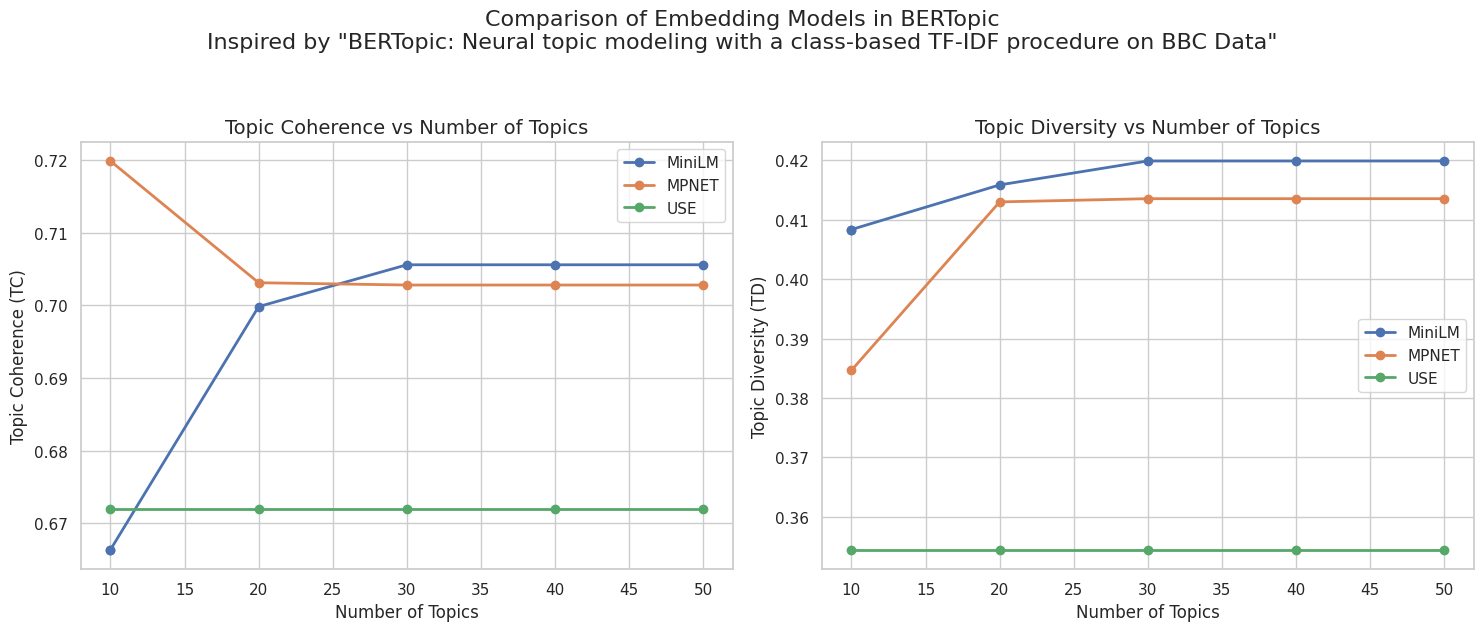

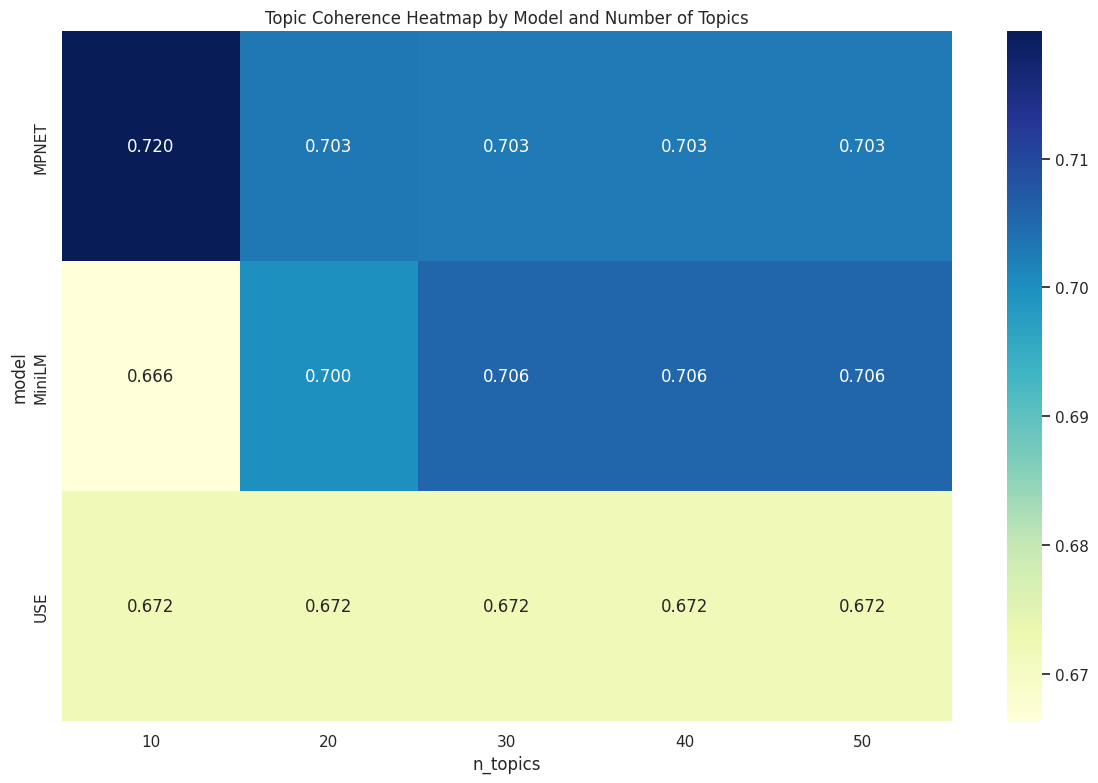

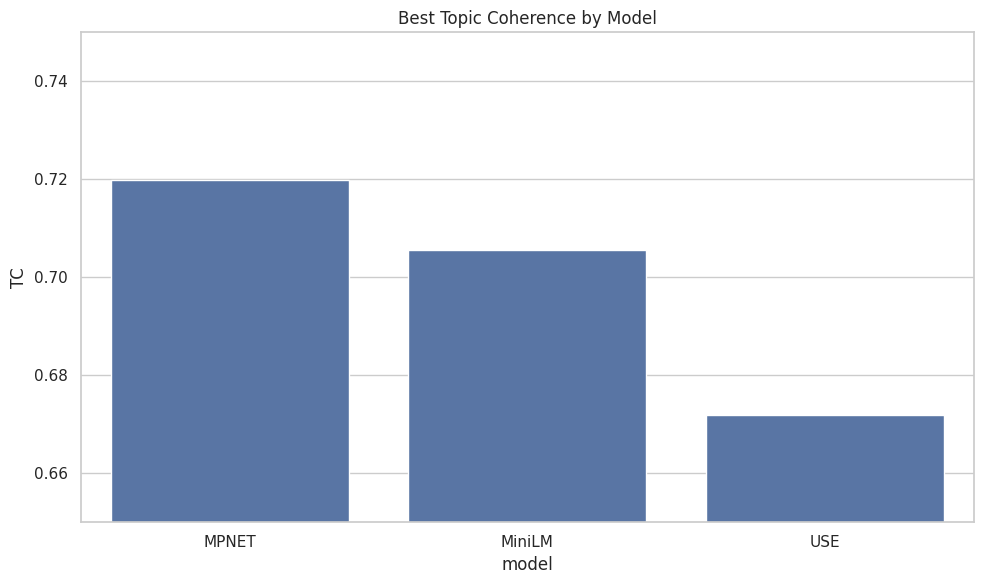

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming your dataframe is named 'df'
# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Set seaborn style for better aesthetics
sns.set(style="whitegrid")

# Plot Topic Coherence (TC)
for model in df_results['model'].unique():
    model_data = df_results[df_results['model'] == model]
    axs[0].plot(model_data['n_topics'], model_data['TC'], marker='o', linewidth=2, label=model)

axs[0].set_xlabel('Number of Topics', fontsize=12)
axs[0].set_ylabel('Topic Coherence (TC)', fontsize=12)
axs[0].set_title('Topic Coherence vs Number of Topics', fontsize=14)
axs[0].legend()
axs[0].grid(True)

# Plot Topic Diversity (TD)
for model in df_results['model'].unique():
    model_data = df_results[df_results['model'] == model]
    axs[1].plot(model_data['n_topics'], model_data['TD'], marker='o', linewidth=2, label=model)

axs[1].set_xlabel('Number of Topics', fontsize=12)
axs[1].set_ylabel('Topic Diversity (TD)', fontsize=12)
axs[1].set_title('Topic Diversity vs Number of Topics', fontsize=14)
axs[1].legend()
axs[1].grid(True)

# Add a main title referencing the BERTopic paper
fig.suptitle('Comparison of Embedding Models in BERTopic\nInspired by "BERTopic: Neural topic modeling with a class-based TF-IDF procedure on BBC Data"',
             fontsize=16, y=1.05)

plt.tight_layout()
plt.savefig('bertopic_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a heatmap for a different view of the data
plt.figure(figsize=(12, 8))
pivot_tc = df_results.pivot_table(index='model', columns='n_topics', values='TC')
sns.heatmap(pivot_tc, annot=True, cmap='YlGnBu', fmt='.3f')
plt.title('Topic Coherence Heatmap by Model and Number of Topics')
plt.tight_layout()
plt.savefig('bertopic_tc_heatmap.png', dpi=300)
plt.show()

# Bar plot for model comparison at optimal n_topics
plt.figure(figsize=(10, 6))
best_configs = df_results.loc[df_results.groupby('model')['TC'].idxmax()]
sns.barplot(x='model', y='TC', data=best_configs)
plt.title('Best Topic Coherence by Model')
plt.ylim(0.65, 0.75)  # Adjust the range as needed
plt.tight_layout()
plt.savefig('bertopic_best_models.png', dpi=300)
plt.show()

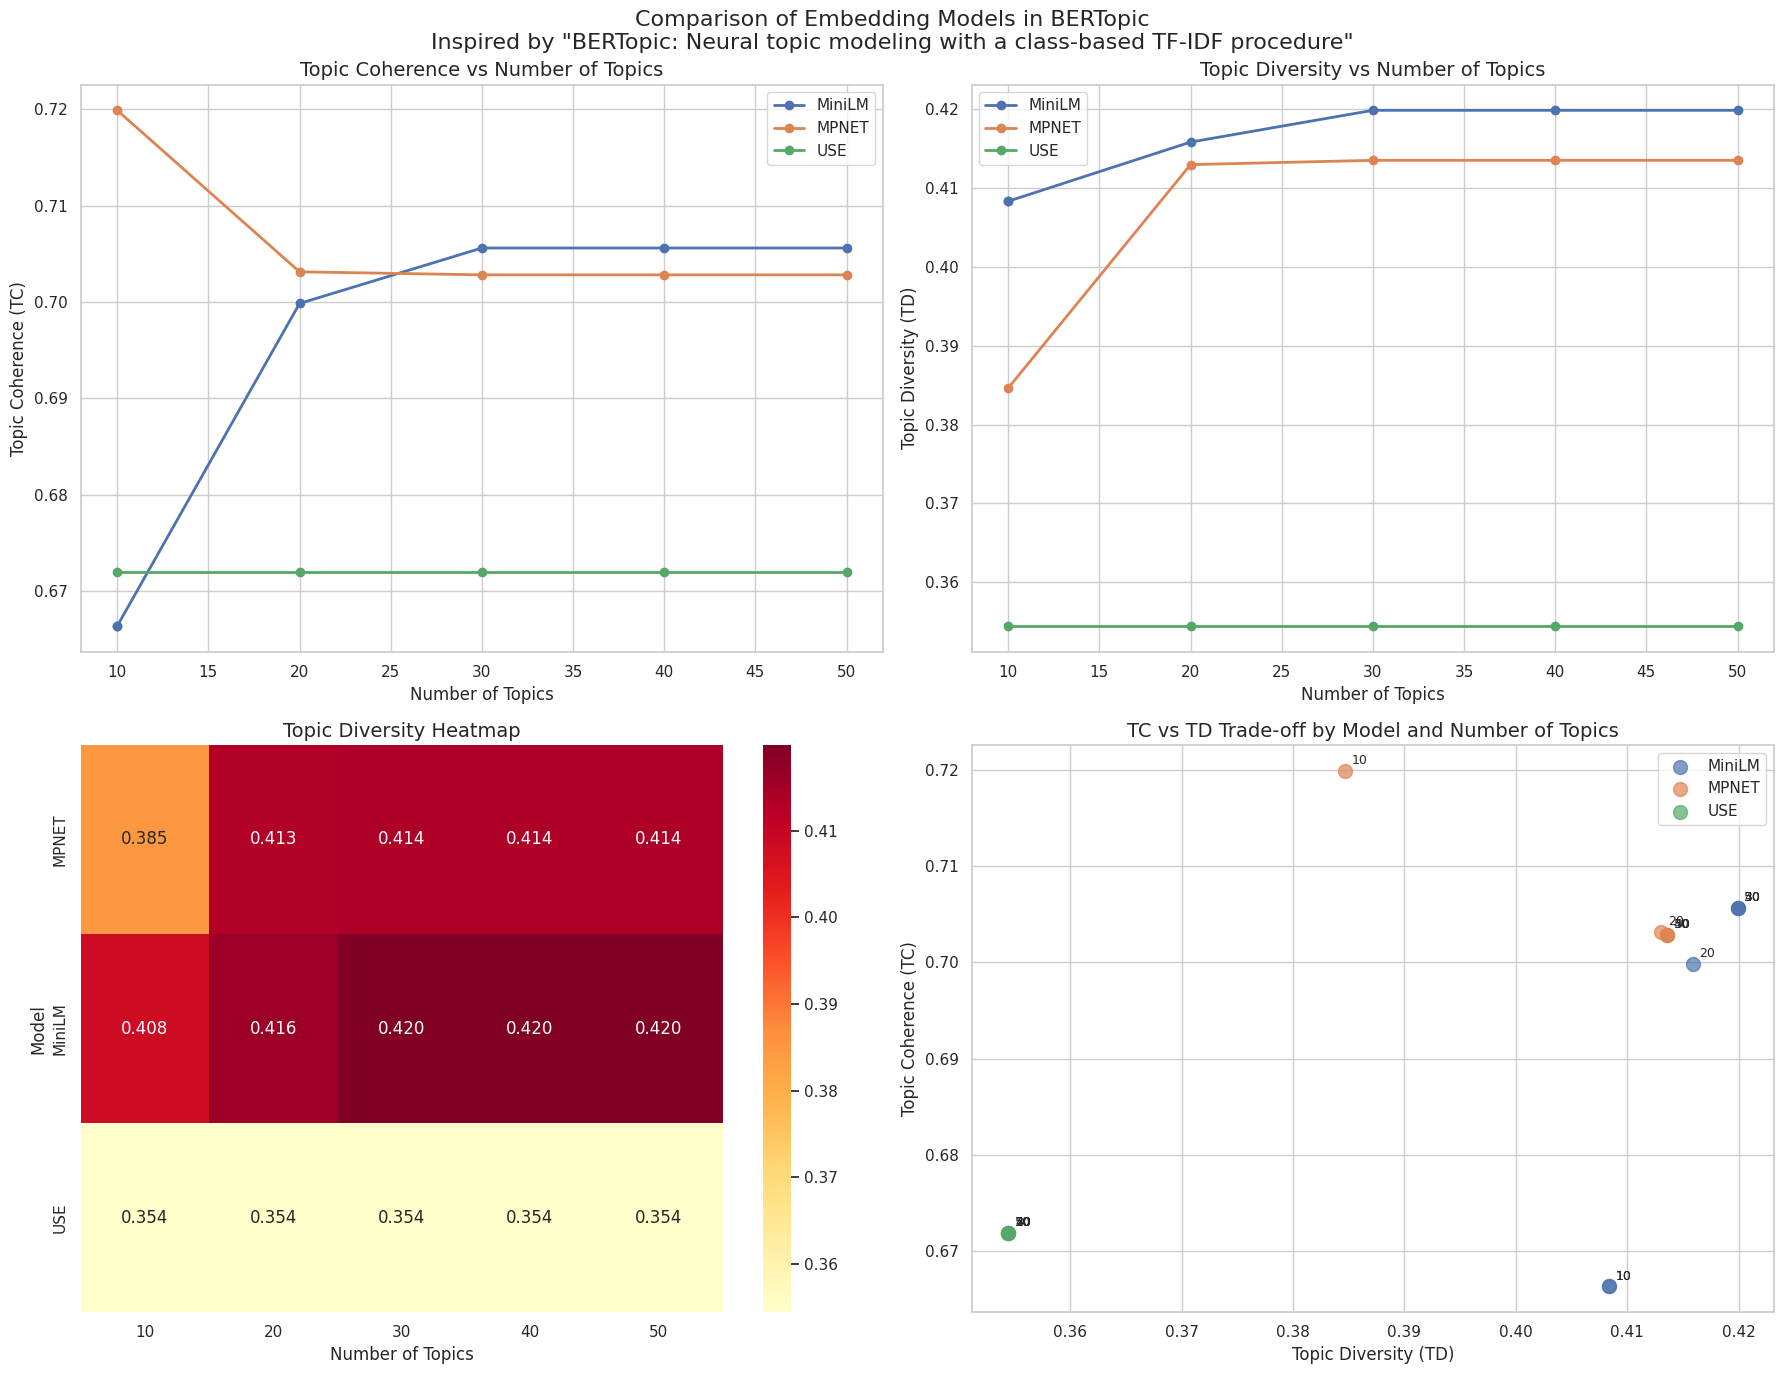

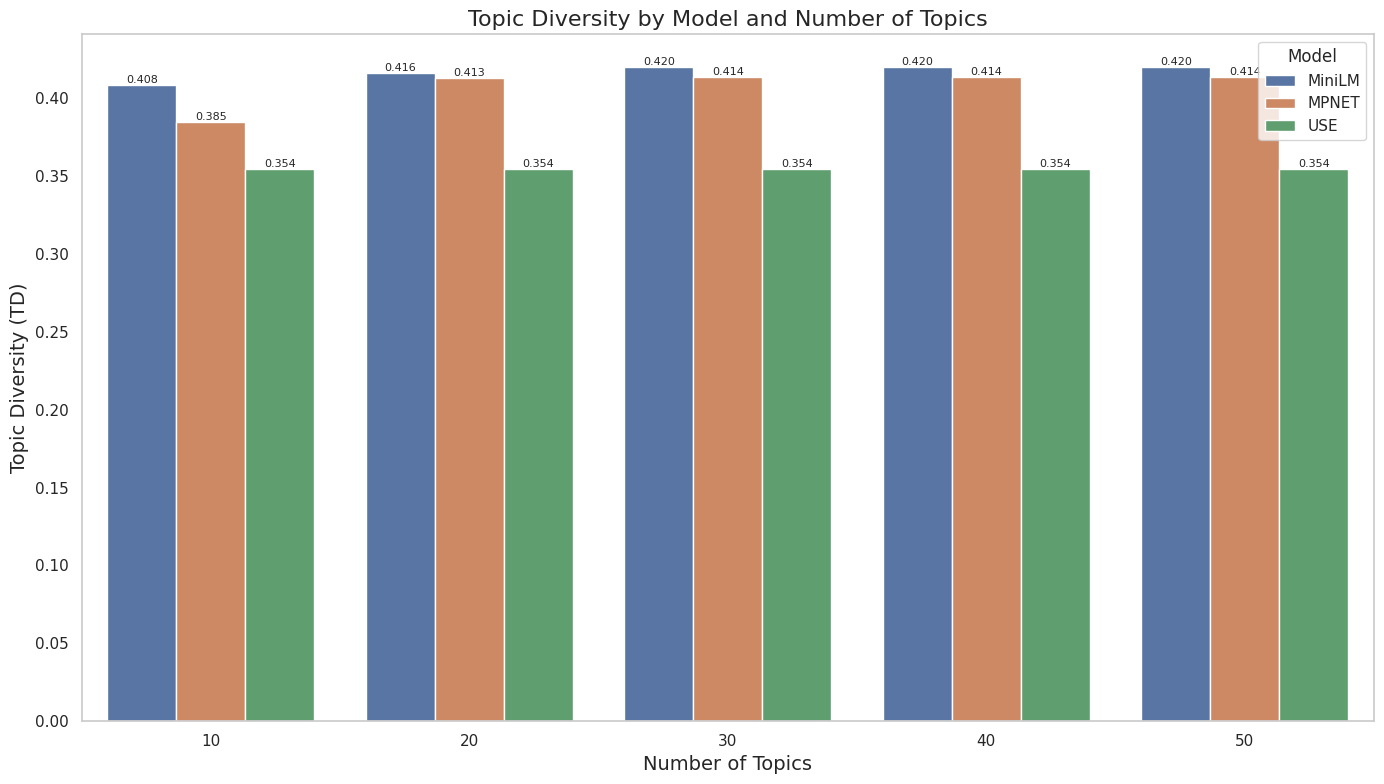

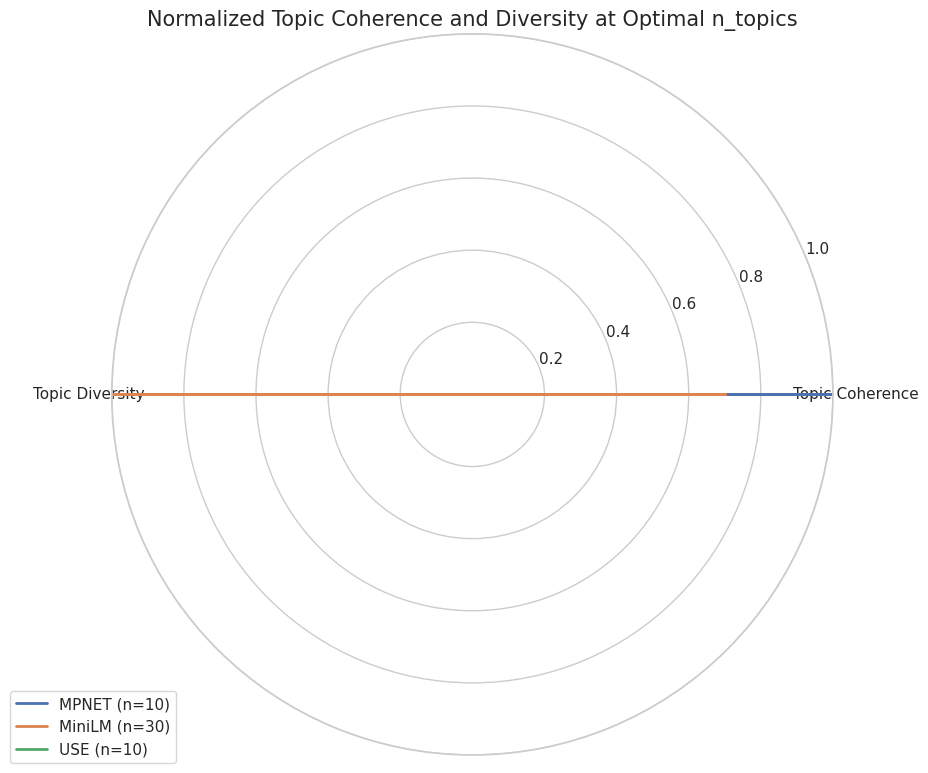

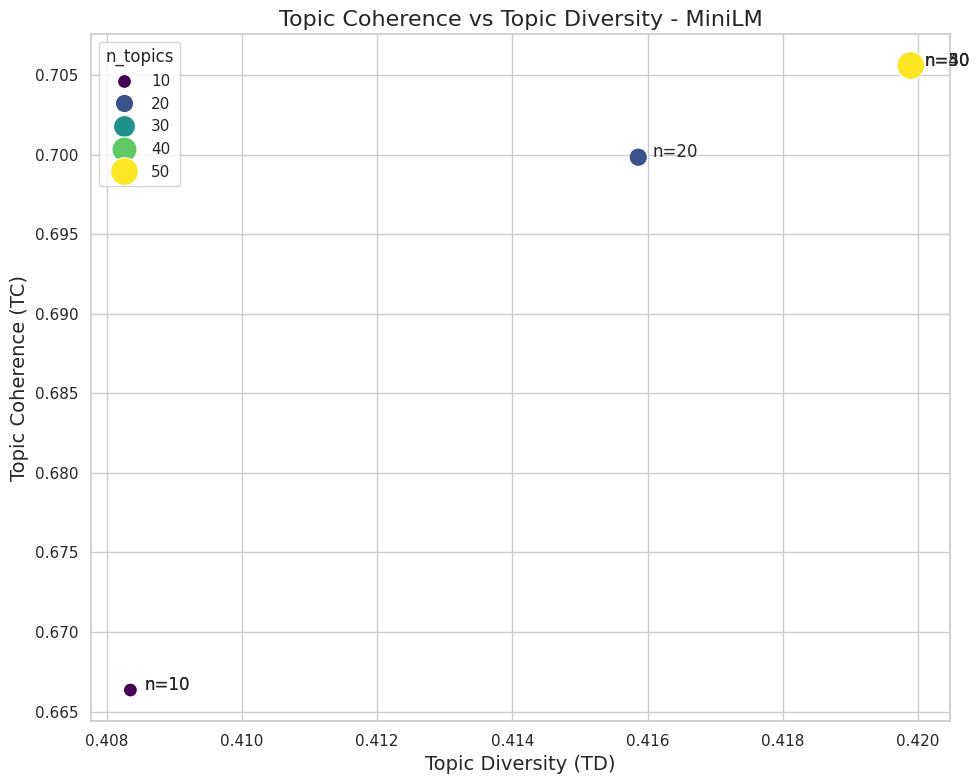

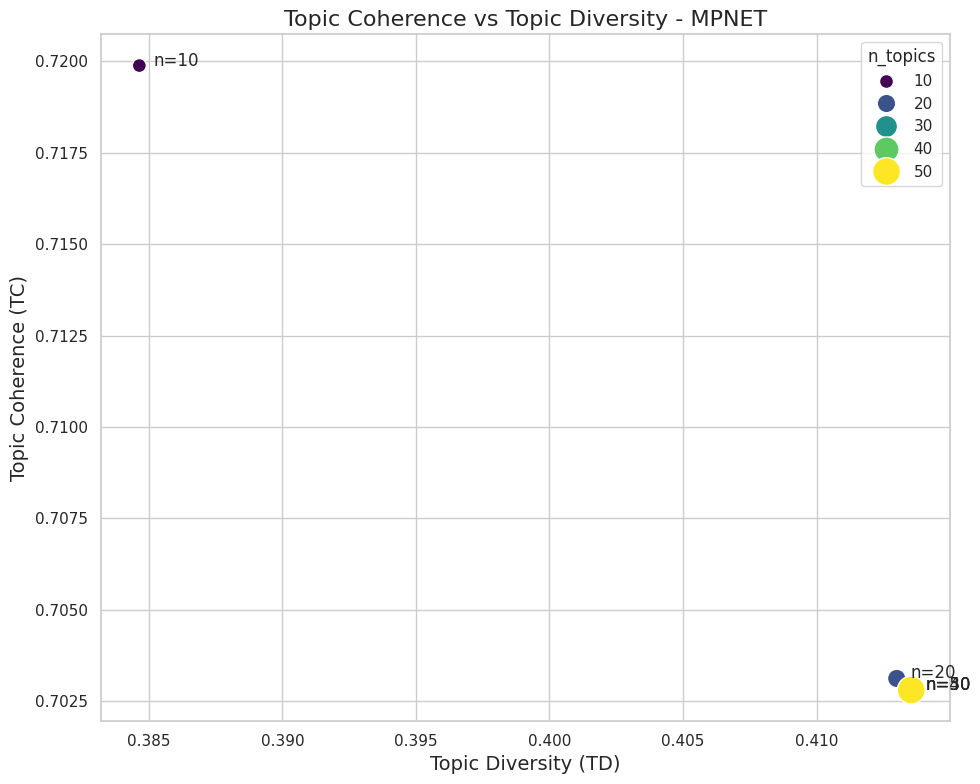

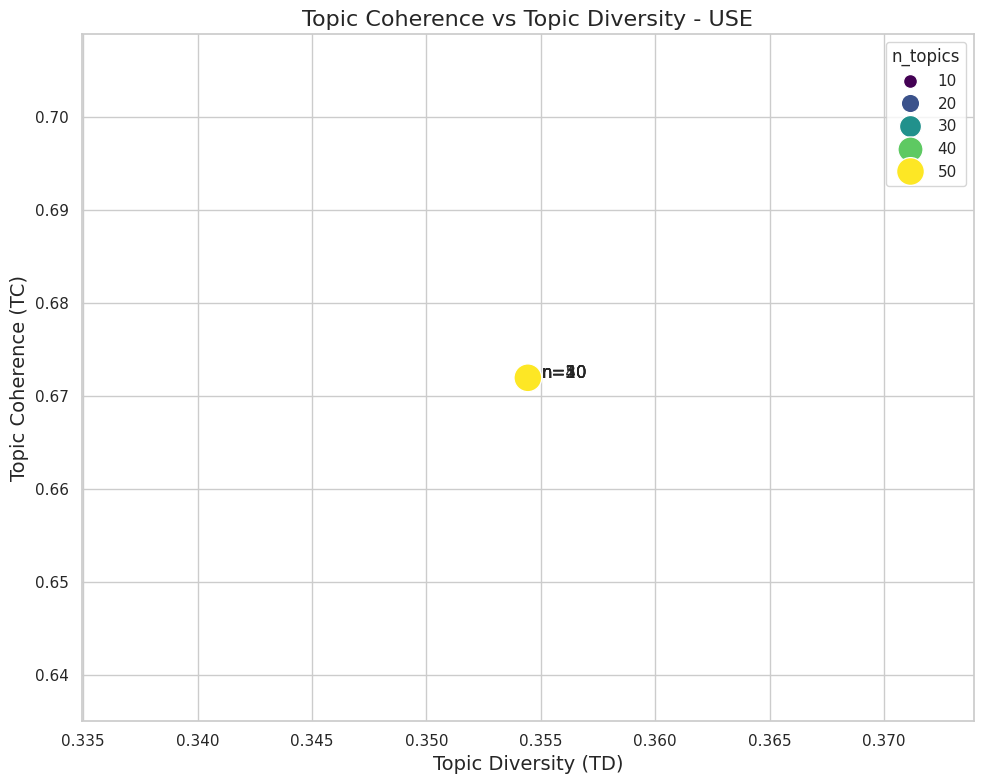

In [33]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np

# Assuming your dataframe is named 'df_results'

# Create a figure with multiple subplots
fig, axs = plt.subplots(2, 2, figsize=(18, 14))

# Set seaborn style for better aesthetics
sns.set(style="whitegrid")

# 1. Line plots for TC and TD
for model in df_results['model'].unique():
    model_data = df_results[df_results['model'] == model]
    axs[0, 0].plot(model_data['n_topics'], model_data['TC'], marker='o', linewidth=2, label=model)
    axs[0, 1].plot(model_data['n_topics'], model_data['TD'], marker='o', linewidth=2, label=model)

axs[0, 0].set_xlabel('Number of Topics', fontsize=12)
axs[0, 0].set_ylabel('Topic Coherence (TC)', fontsize=12)
axs[0, 0].set_title('Topic Coherence vs Number of Topics', fontsize=14)
axs[0, 0].legend()
axs[0, 0].grid(True)

axs[0, 1].set_xlabel('Number of Topics', fontsize=12)
axs[0, 1].set_ylabel('Topic Diversity (TD)', fontsize=12)
axs[0, 1].set_title('Topic Diversity vs Number of Topics', fontsize=14)
axs[0, 1].legend()
axs[0, 1].grid(True)

# 2. Heatmap for TD
pivot_td = df_results.pivot_table(index='model', columns='n_topics', values='TD')
sns.heatmap(pivot_td, annot=True, cmap='YlOrRd', fmt='.3f', ax=axs[1, 0])
axs[1, 0].set_title('Topic Diversity Heatmap', fontsize=14)
axs[1, 0].set_ylabel('Model', fontsize=12)
axs[1, 0].set_xlabel('Number of Topics', fontsize=12)

# 3. Scatter plot of TC vs TD to visualize trade-offs
for model in df_results['model'].unique():
    model_data = df_results[df_results['model'] == model]
    axs[1, 1].scatter(model_data['TD'], model_data['TC'], label=model, s=100, alpha=0.7)

    # Add annotations for n_topics
    for i, row in model_data.iterrows():
        axs[1, 1].annotate(f"{int(row['n_topics'])}",
                         (row['TD'], row['TC']),
                         xytext=(5, 5),
                         textcoords='offset points',
                         fontsize=9)

axs[1, 1].set_xlabel('Topic Diversity (TD)', fontsize=12)
axs[1, 1].set_ylabel('Topic Coherence (TC)', fontsize=12)
axs[1, 1].set_title('TC vs TD Trade-off by Model and Number of Topics', fontsize=14)
axs[1, 1].legend()
axs[1, 1].grid(True)

# Add a main title referencing the BERTopic paper
fig.suptitle('Comparison of Embedding Models in BERTopic\nInspired by "BERTopic: Neural topic modeling with a class-based TF-IDF procedure"',
             fontsize=16, y=0.98)

plt.tight_layout()
plt.savefig('bertopic_comprehensive_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional visualizations specifically for Topic Diversity

# Bar chart comparing TD across models at different n_topics
plt.figure(figsize=(14, 8))
ax = sns.barplot(x='n_topics', y='TD', hue='model', data=df_results)
plt.title('Topic Diversity by Model and Number of Topics', fontsize=16)
plt.xlabel('Number of Topics', fontsize=14)
plt.ylabel('Topic Diversity (TD)', fontsize=14)
plt.legend(title='Model')
plt.grid(axis='y')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8)
plt.tight_layout()
plt.savefig('bertopic_td_comparison.png', dpi=300)
plt.show()

# Create a radar chart for TC and TD at optimal n_topics
best_configs = df_results.loc[df_results.groupby('model')['TC'].idxmax()]

# Normalize the values for radar chart
best_configs['TC_norm'] = (best_configs['TC'] - best_configs['TC'].min()) / (best_configs['TC'].max() - best_configs['TC'].min())
best_configs['TD_norm'] = (best_configs['TD'] - best_configs['TD'].min()) / (best_configs['TD'].max() - best_configs['TD'].min())

# Create radar chart
categories = ['Topic Coherence', 'Topic Diversity']
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, polar=True)

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]  # close the loop

for i, model in enumerate(best_configs['model']):
    values = best_configs.loc[best_configs['model'] == model, ['TC_norm', 'TD_norm']].values.flatten().tolist()
    values += values[:1]  # close the loop
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=f"{model} (n={int(best_configs.loc[best_configs['model'] == model, 'n_topics'].values[0])})")
    ax.fill(angles, values, alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), categories)
ax.set_ylim(0, 1)
ax.set_title('Normalized Topic Coherence and Diversity at Optimal n_topics', size=15)
ax.grid(True)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.tight_layout()
plt.savefig('bertopic_radar_comparison.png', dpi=300)
plt.show()

# Create a joint plot to better visualize the relationship between n_topics, TC, and TD
for model in df_results['model'].unique():
    model_data = df_results[df_results['model'] == model]
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=model_data, x='TD', y='TC', size='n_topics', sizes=(100, 400), hue='n_topics', palette='viridis')
    plt.title(f'Topic Coherence vs Topic Diversity - {model}', fontsize=16)
    plt.xlabel('Topic Diversity (TD)', fontsize=14)
    plt.ylabel('Topic Coherence (TC)', fontsize=14)

    # Add annotations for n_topics
    for i, row in model_data.iterrows():
        plt.annotate(f"n={int(row['n_topics'])}",
                     (row['TD'], row['TC']),
                     xytext=(10, 0),
                     textcoords='offset points')

    plt.tight_layout()
    plt.savefig(f'bertopic_{model}_tc_td_relationship.png', dpi=300)
    plt.show()